In [37]:
import pandas as pd 
import boto3
import s3fs
import matplotlib.pyplot as plt 
import seaborn as sns 

In [38]:
df = pd.read_csv("s3://ads508-bereket-bucket/project-raw-data/Logistics_supply_chain.csv")
df.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


In [39]:
df.shape

(32065, 26)

In [40]:
df.columns 

Index(['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'warehouse_inventory_level',
       'loading_unloading_time', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'port_congestion_level', 'shipping_costs', 'supplier_reliability_score',
       'lead_time_days', 'historical_demand', 'iot_temperature',
       'cargo_condition_status', 'route_risk_level', 'customs_clearance_time',
       'driver_behavior_score', 'fatigue_monitoring_score',
       'disruption_likelihood_score', 'delay_probability',
       'risk_classification', 'delivery_time_deviation'],
      dtype='object')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs    

In [42]:
df.isnull().sum()

timestamp                          0
vehicle_gps_latitude               0
vehicle_gps_longitude              0
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unloading_time             0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
port_congestion_level              0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
iot_temperature                    0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
driver_behavior_score              0
fatigue_monitoring_score           0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
dtype: int64

In [43]:
df.describe()

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,...,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,32065.000000,32065.000000,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,3.206500e+04,32065.000000,3.206500e+04,...,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,32065.000000,32065.000000
mean,38.023589,-90.116648,8.011735,2.893068,4.991493e+00,2.992547e+02,2.291669,3.026954e-01,0.600740,4.976082e-01,...,6022.001286,0.044792,2.972816e-01,7.001144,2.296448,4.983913e-01,6.008723e-01,0.803656,0.699077,5.177648
std,6.917909,17.369244,4.264960,2.274044,3.532048e+00,3.234435e+02,1.554202,3.259146e-01,0.345672,3.532853e-01,...,3427.638017,14.187486,3.216115e-01,3.236328,1.555932,3.541589e-01,3.458101e-01,0.279185,0.324514,4.157988
min,30.000000,-119.999998,5.000000,-1.999993,1.091633e-09,1.322210e-12,0.500000,4.565769e-16,0.000001,4.536949e-09,...,100.002966,-10.000000,7.255415e-19,0.000050,0.500000,4.043927e-09,3.269508e-07,0.000048,0.000003,-1.999998
25%,31.280550,-106.253913,5.019984,1.185744,1.474720e+00,1.605163e+01,0.774798,1.710828e-02,0.277096,1.440135e-01,...,2822.607616,-9.931074,1.678269e-02,4.593407,0.776166,1.443567e-01,2.783148e-01,0.693739,0.456009,1.269197
50%,36.413820,-86.293414,5.636036,3.882059,4.981244e+00,1.572880e+02,1.917121,1.595151e-01,0.680553,4.961781e-01,...,6785.123209,-7.858681,1.549760e-01,8.385605,1.938273,4.988468e-01,6.831130e-01,0.958128,0.839599,6.113662
75%,44.453655,-73.079367,9.669944,4.884355,8.534902e+00,5.405980e+02,3.734188,5.535954e-01,0.938160,8.498226e-01,...,9374.252913,6.024012,5.405408e-01,9.836152,3.750817,8.510762e-01,9.372889e-01,0.998746,0.982391,9.249206
max,50.000000,-70.000000,19.999875,5.000000,9.999999e+00,9.999993e+02,5.000000,9.999995e-01,1.000000,1.000000e+00,...,10000.000000,39.999886,1.000000e+00,10.000000,5.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,10.000000


## Convert timestamp to datetime

In [44]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

## Delay Distribution

The histogram shows that delivery time deviations range from -2 to 10 hours, with most deliveries experiencing delays between 7 and 10 hours.

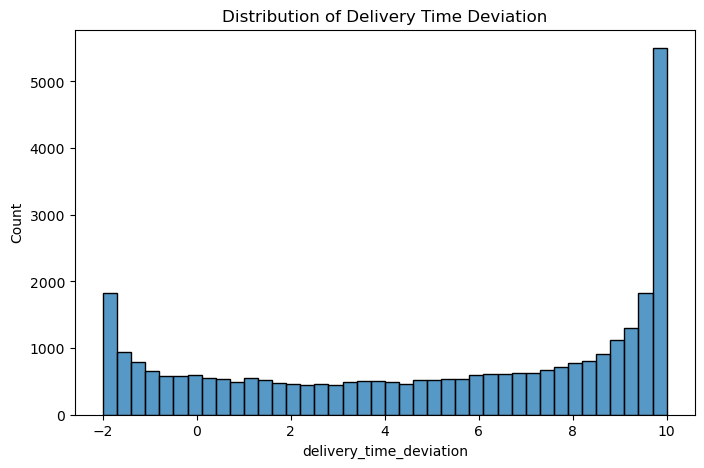

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time_deviation'], bins=40)
plt.title("Distribution of Delivery Time Deviation")
plt.show()

## Traffic congestion Vs 

Traffic congestion levels show a slight positive relationship with delivery delays, indicating that higher road congestion may increase delivery time deviations.

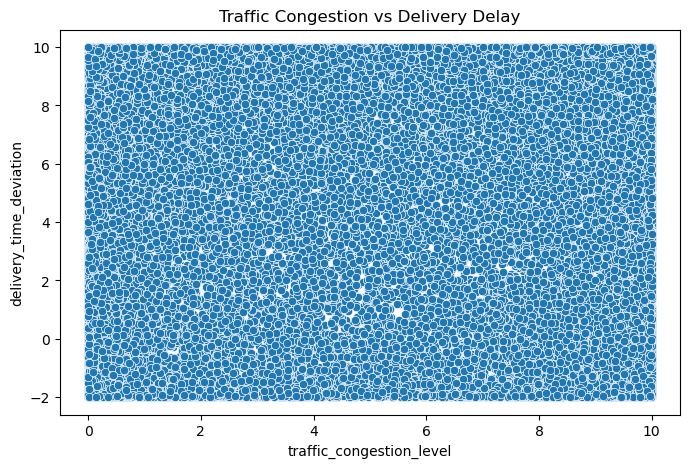

In [46]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['traffic_congestion_level'], y=df['delivery_time_deviation'])
plt.title("Traffic Congestion vs Delivery Delay")
plt.show()

## Lead time analysis

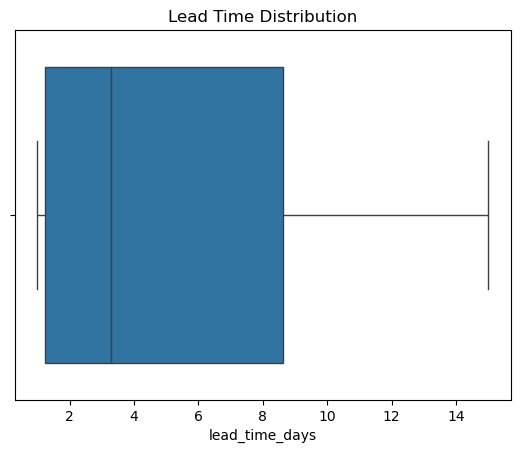

In [47]:
sns.boxplot(x=df['lead_time_days'])
plt.title("Lead Time Distribution")
plt.show()

## Correlation heatmap

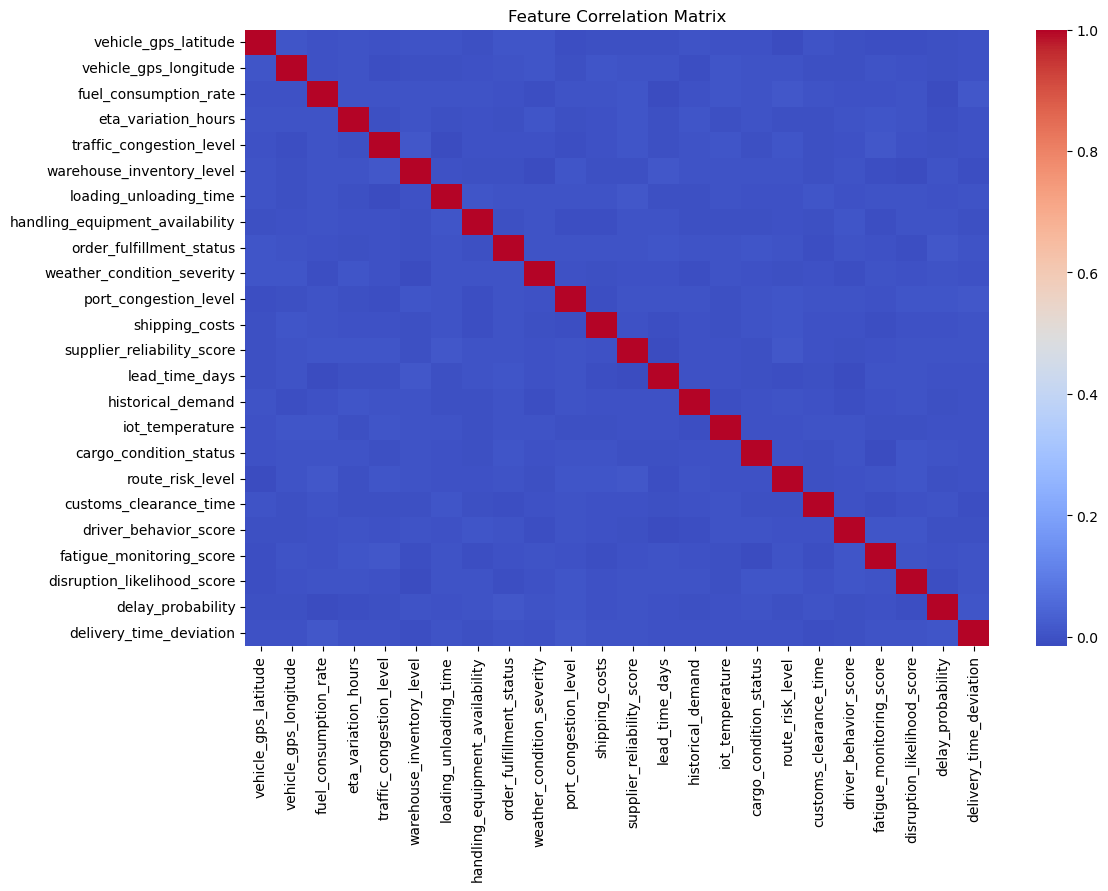

In [48]:
df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

## Top factors affecting delay

In [49]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

corr['delivery_time_deviation'].sort_values(ascending=False)

delivery_time_deviation            1.000000
fuel_consumption_rate              0.012495
port_congestion_level              0.010612
delay_probability                  0.005530
supplier_reliability_score         0.004384
fatigue_monitoring_score           0.003491
loading_unloading_time             0.003375
order_fulfillment_status           0.003329
disruption_likelihood_score        0.002622
shipping_costs                     0.002504
historical_demand                  0.000615
traffic_congestion_level           0.000510
vehicle_gps_latitude               0.000416
route_risk_level                  -0.000076
weather_condition_severity        -0.000541
iot_temperature                   -0.000569
eta_variation_hours               -0.000746
cargo_condition_status            -0.001348
vehicle_gps_longitude             -0.001639
lead_time_days                    -0.002460
driver_behavior_score             -0.003969
handling_equipment_availability   -0.004639
warehouse_inventory_level       

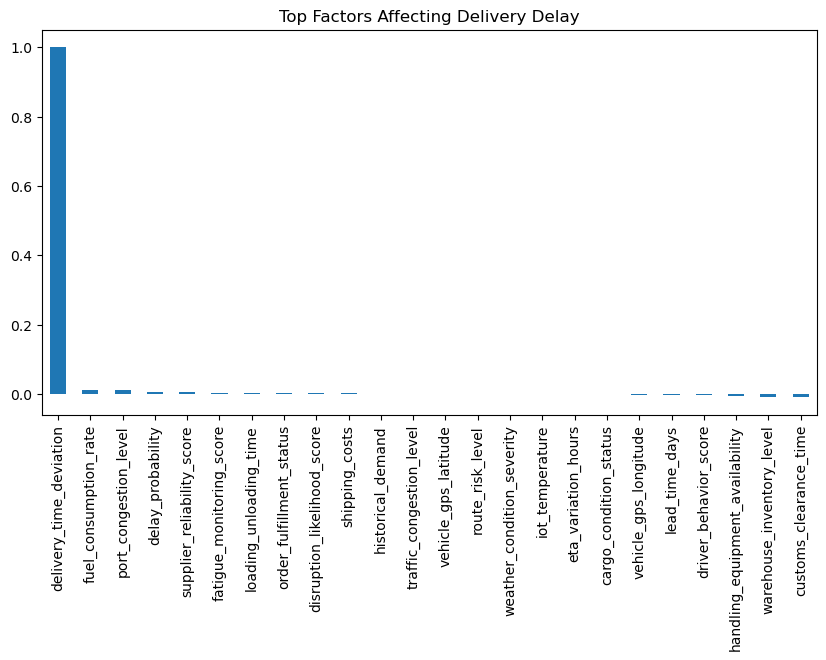

In [50]:
corr['delivery_time_deviation'].sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Top Factors Affecting Delivery Delay")
plt.show()

## Shipping cost Vs Delay

The scatter plot shows no strong direct relationship between shipping costs and delivery delay, suggesting that cost is not a primary predictor of delays in this dataset.

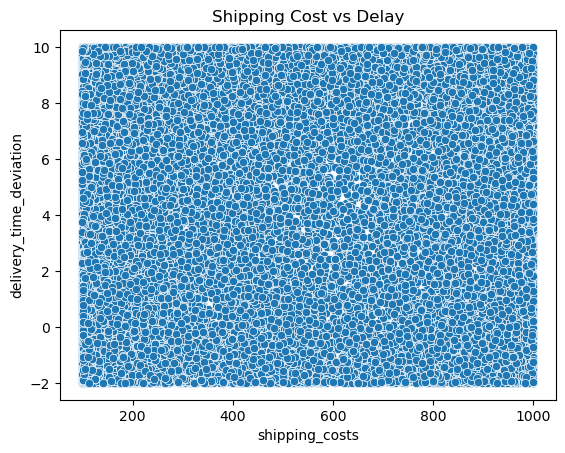

In [51]:
sns.scatterplot(x=df['shipping_costs'], y=df['delivery_time_deviation'])
plt.title("Shipping Cost vs Delay")
plt.show()

## Port congestion impact

The boxplot suggests that higher port congestion levels generally correspond to increased delivery time deviations, indicating that port bottlenecks may contribute to shipment delays.

In [52]:
df['port_congestion_level'] = df['port_congestion_level'].astype(int)

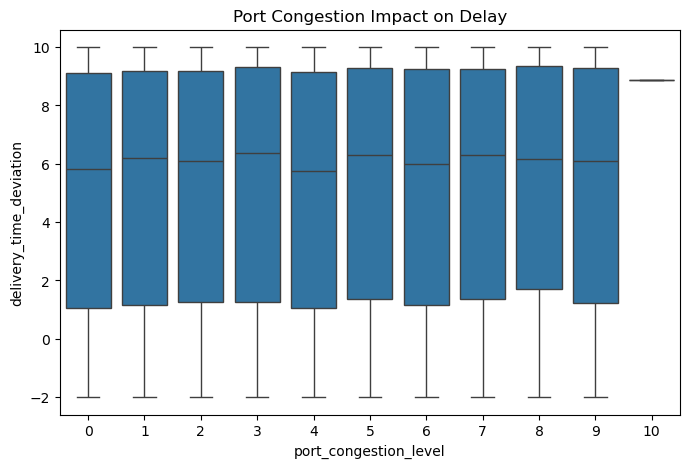

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['port_congestion_level'], y=df['delivery_time_deviation'])
plt.title("Port Congestion Impact on Delay")
plt.show()

## Weather vs Delay

The scatter plot shows the relationship between weather severity and delivery time deviation. Although delays occur across all weather conditions, more severe weather appears to slightly increase delivery delays.

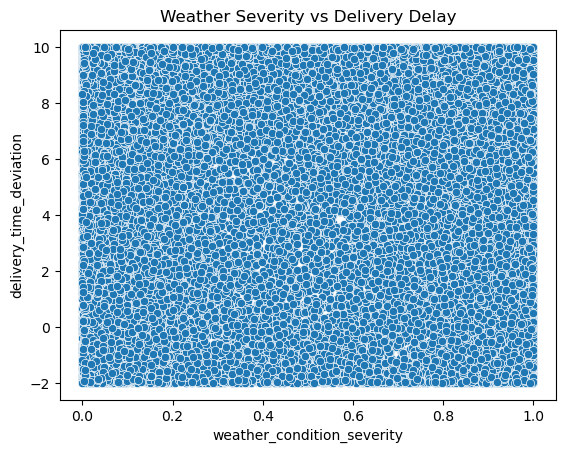

In [54]:
sns.scatterplot(x=df['weather_condition_severity'], y=df['delivery_time_deviation'])
plt.title("Weather Severity vs Delivery Delay")
plt.show()

## Supplier Reliability vs Delay

Supplier reliability appears to have a weak relationship with delivery delays. While higher reliability scores may reduce some delays, other operational factors such as congestion and logistics conditions likely have stronger impacts.

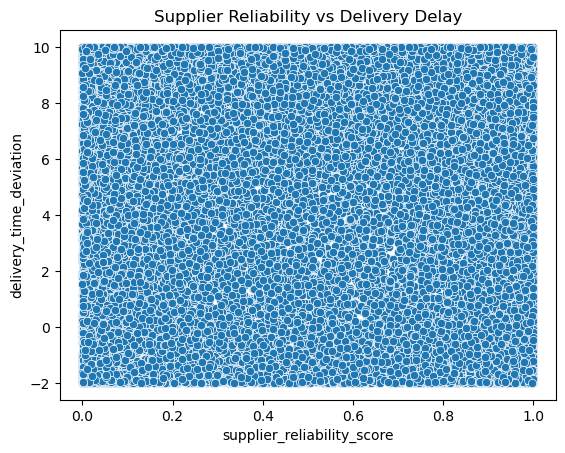

In [55]:
sns.scatterplot(x=df['supplier_reliability_score'], y=df['delivery_time_deviation'])
plt.title("Supplier Reliability vs Delivery Delay")
plt.show()

## Geographic Distribution of Delivery Delays

This geographic scatter plot shows how delivery time deviations vary across shipment locations based on GPS coordinates. Areas with warmer colors indicate relatively higher delivery delays, while cooler colors indicate lower delays. This visualization helps identify whether certain geographic regions may experience more shipment delays than others.

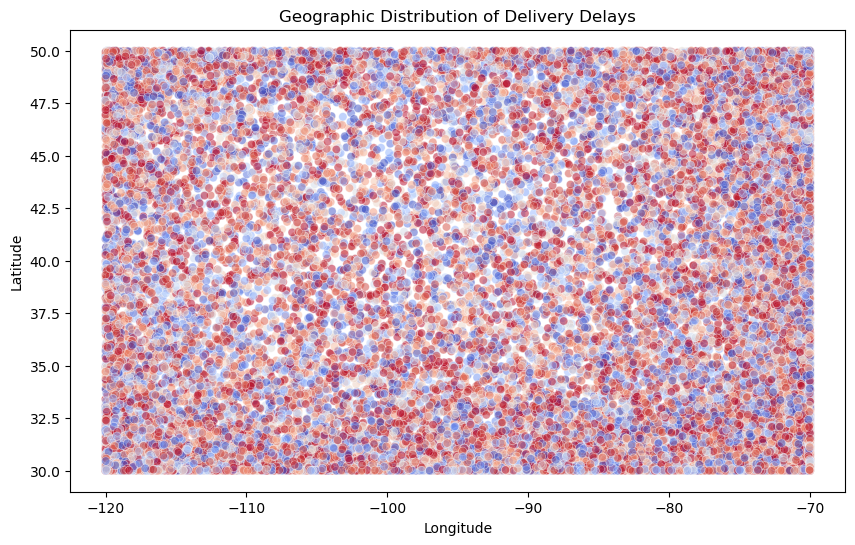

In [58]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['vehicle_gps_longitude'],
    y=df['vehicle_gps_latitude'],
    hue=df['delivery_time_deviation'],
    palette='coolwarm',
    alpha=0.5,
    legend=False
)

plt.title("Geographic Distribution of Delivery Delays")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()